In [1]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import pickle
from tqdm import tqdm

import numpy as np
np.float = np.float64

import healpy as hp
import jax.numpy as jnp

sys.path.append("/n/home07/yitians/fermi/NPTFit/NPTFit")
sys.path.append("/n/home07/yitians/fermi/NPTFit")
from NPTFit import npll

sys.path.append("../nptfit")
from nptfit_func import *

sys.path.append("..")
from utils import create_mask as cm
from models.templates import NFWTemplate, LorimerDiskTemplate
from models.psf import KingPSF
from utils.utils import find_max_point

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file('../notebooks/matplotlibrc')

In [10]:
size_len = 0.5 # deg
sigma = 0.0003 # deg

n_ps = 6565
n_tot_phot = 28801
EPSILON = 1e-10

n_tot_in = 0
n_tot = 0
exp_phot = n_tot_phot / n_ps
xy = np.random.uniform(0, size_len, (n_ps, 2))
all_phxy = []
for i in (range(n_ps)):
    n_draw = np.random.poisson(exp_phot)
    phxy = np.random.normal(0, sigma, (n_draw, 2)) + (xy[i])[None, :]
    all_phxy.append(phxy)
    is_in = (0-EPSILON < phxy[:, 0]) & (phxy[:, 0] < size_len+EPSILON) & (0-EPSILON < phxy[:, 1]) & (phxy[:, 1] < size_len+EPSILON)
    n_in = np.sum(is_in)
    n_tot_in += n_in
    n_tot += n_draw

print('out:', n_tot - n_tot_in)

out: 28


In [11]:
all_phxy = np.concatenate(all_phxy, axis=0)

(-0.025267949842616107,
 0.525453058833265,
 -0.02544506413140341,
 0.525125402263665)

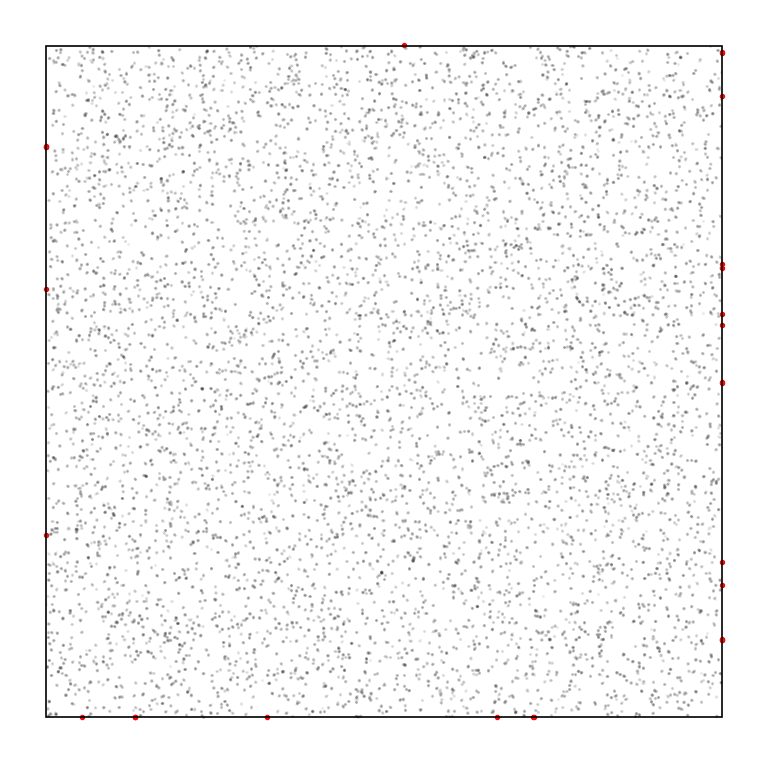

In [13]:
is_in = (0-EPSILON < all_phxy[:, 0]) & (all_phxy[:, 0] < size_len+EPSILON) & (0-EPSILON < all_phxy[:, 1]) & (all_phxy[:, 1] < size_len+EPSILON)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(all_phxy[:, 0][is_in], all_phxy[:, 1][is_in], s=0.2, alpha=0.1, c='k')
ax.scatter(all_phxy[:, 0][~is_in], all_phxy[:, 1][~is_in], s=5, alpha=1, c='r')
ax.scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.1, c='gray')
# add a square of size_len
ax.add_patch(mpl.patches.Rectangle((0, 0), size_len, size_len, fill=False, edgecolor='k', lw=1))
ax.axis('off')

In [14]:
size_len = 0.5 # deg
sigma = 0.0003 # deg

n_ps = 6565
n_tot_phot = 28801
EPSILON = 1e-10

n_out_s = []
for _ in tqdm(range(1000)):
    n_tot_in = 0
    n_tot = 0
    exp_phot = n_tot_phot / n_ps
    xy = np.random.uniform(0, size_len, (n_ps, 2))
    all_phxy = []
    for i in (range(n_ps)):
        n_draw = np.random.poisson(exp_phot)
        phxy = np.random.normal(0, sigma, (n_draw, 2)) + (xy[i])[None, :]
        all_phxy.append(phxy)
        is_in = (0-EPSILON < phxy[:, 0]) & (phxy[:, 0] < size_len+EPSILON) & (0-EPSILON < phxy[:, 1]) & (phxy[:, 1] < size_len+EPSILON)
        n_in = np.sum(is_in)
        n_tot_in += n_in
        n_tot += n_draw
    n_out_s.append(n_tot - n_tot_in)

100%|██████████| 1000/1000 [01:29<00:00, 11.13it/s]


(array([  2.,   3.,   2.,  13.,  10.,  22.,  16.,  52.,  67.,  42.,  88.,
         53.,  94.,  56., 105.,  93.,  25.,  79.,  20.,  41.,  19.,  38.,
         19.,   3.,  15.,   7.,  10.,   1.,   3.,   2.]),
 array([ 6.        ,  7.56666667,  9.13333333, 10.7       , 12.26666667,
        13.83333333, 15.4       , 16.96666667, 18.53333333, 20.1       ,
        21.66666667, 23.23333333, 24.8       , 26.36666667, 27.93333333,
        29.5       , 31.06666667, 32.63333333, 34.2       , 35.76666667,
        37.33333333, 38.9       , 40.46666667, 42.03333333, 43.6       ,
        45.16666667, 46.73333333, 48.3       , 49.86666667, 51.43333333,
        53.        ]),
 <BarContainer object of 30 artists>)

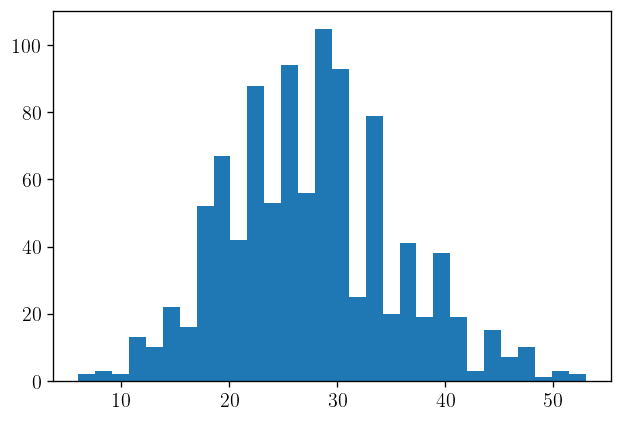

In [15]:
plt.hist(n_out_s, bins=30)